In [1]:
from pathlib import Path

class CONLLUParser:
    def __init__(self):
        self.sentences = []
        self.texts = []

    def __make_wordform(self, parts):
        return {
            "id": int(parts[0]),
            "form": parts[1],
            "lemma": parts[2],
            "upos": parts[3],
            "head": int(parts[6]) if parts[6] != "_" else 0,
            "deprel": parts[7]
        }

    def __read_sentence(self, lines, pos):
        sent = []
        text = ""

        while pos < len(lines):
            line = lines[pos].rstrip("\n")

            if line == "":
                pos += 1
                break

            if line.startswith("# text = "):
                text = line[9:].strip()
            elif not line.startswith("#"):
                parts = line.split("\t")
                if len(parts) >= 8 and "-" not in parts[0] and "." not in parts[0]:
                    try:
                        sent.append(self.__make_wordform(parts))
                    except:
                        pass

            pos += 1

        return sent, text, pos

    def parse_conllu_file(self, filename):
        with open(filename, "r", encoding="utf-8") as f:
            lines = f.readlines()

        self.sentences = []
        self.texts = []

        pos = 0
        while pos < len(lines):
            sent, text, pos = self.__read_sentence(lines, pos)
            if sent:
                self.sentences.append(sent)
                self.texts.append(text)

    def find_construction(self, child_upos, child_deprel, parent_upos):
        results = []

        for sent_idx, sent in enumerate(self.sentences):
            id2word = {w["id"]: w for w in sent}

            for child in sent:
                if child["upos"] == child_upos and child["deprel"] == child_deprel:
                    parent = id2word.get(child["head"])
                    if parent and parent["upos"] == parent_upos:
                        results.append({
                            "text": self.texts[sent_idx],
                            "sentence": [w["form"] for w in sent],
                            "match": child,
                            "parent": parent
                        })
                        break

        return results


class ConstructionFinder:
    def __init__(self):
        self.parser = CONLLUParser()
        self.results = {}

    def find_in_directory(self, path, child_upos, child_deprel, parent_upos, filename_mask="*Gaydar*.conllu"):
        all_results = {}

        for file_path in Path(path).glob(filename_mask):
            self.parser.parse_conllu_file(str(file_path))
            found = self.parser.find_construction(child_upos, child_deprel, parent_upos)
            all_results[str(file_path)] = found
            self.results[str(file_path)] = found

        return all_results

In [6]:
from typing import Dict, List, Tuple

# Объявите ваш finder один раз
finder = ConstructionFinder()

# Список признаков: (parent_upos, direction, child_upos, deprel, label)
# direction: "<-" = parent ← child, "->" = parent → child
patterns = [
    # NOUN -> INTJ, nsubj
    ("NOUN", "->", "INTJ", "nsubj", "NOUN -> INTJ, nsubj"),

    # PRON -> PRON, fixed
    ("PRON", "->", "PRON", "fixed", "PRON -> PRON, fixed"),

    # DET -> ADJ, acl:relcl
    ("DET", "->", "ADJ", "acl:relcl", "DET -> ADJ, acl:relcl"),

    # ADJ -> VERB, obl
    ("ADJ", "->", "VERB", "obl", "ADJ -> VERB, obl"),

    # X <- VERB, root
    ("X", "<-", "VERB", "root", "X <- VERB, root"),

    # VERB <- PRON, iobj
    ("VERB", "<-", "PRON", "iobj", "VERB <- PRON, iobj"),

    # VERB -> VERB, ccomp
    ("VERB", "->", "VERB", "ccomp", "VERB -> VERB, ccomp"),

    # ADV <- PROPN, obl
    ("ADV", "<-", "PROPN", "obl", "ADV <- PROPN, obl"),

    # NOUN -> INTJ, nsubj
    ("NOUN", "->", "INTJ", "nsubj", "NOUN -> INTJ, nsubj"),

    # X -> NOUN, parataxis
    ("X", "->", "NOUN", "parataxis", "X -> NOUN, parataxis"),

    # PRON <- PRON, parataxis
    ("PRON", "<-", "PRON", "parataxis", "PRON <- PRON, parataxis"),

    # X -> ADV, parataxis
    ("X", "->", "ADV", "parataxis", "X -> ADV, parataxis"),

    # SYM -> PROPN, nsubj
    ("SYM", "->", "PROPN", "nsubj", "SYM -> PROPN, nsubj"),

    # PRON -> PAD, amod
    ("PRON", "->", "PAD", "amod", "PRON -> PAD, amod"),

    # ADJ -> DET, nummod:gov
    ("ADJ", "->", "DET", "nummod:gov", "ADJ -> DET, nummod:gov"),
]

In [7]:
filename_masks = ["*Turgenev*.conllu", "*.conllu"]

for parent_upos, direction, child_upos, deprel, label in patterns:
    print(f"\n{label}")
    
    example_found = False
    
    # Попробовать сначала Gaydar, потом все файлы
    for mask in filename_masks:
        # Интерпретируем направление стрелки
        if direction == "<-":
            parent, child = child_upos, parent_upos
        else:  # "->"
            parent, child = parent_upos, child_upos

        # Пускаем поиск
        results = finder.find_in_directory(
            "./conllu_DeepPavlov",
            child_upos=child,
            child_deprel=deprel,
            parent_upos=parent,
            filename_mask=mask,
        )
        amount = [len(items) for items in results.values()]
        amount = sum(amount)            
        print(amount)

        # Берем первый файл и первый пример
        for filename, items in results.items():
            if not items:
                continue
            item = items[0]
            print(f'"{item["text"]}"')
            print("MATCH:", item["match"])
            print("PARENT:", item["parent"])
            print(f"Файл: {filename}")

            print("-" * 50)

            example_found = True
            break  # один пример на признак

        if example_found:
            break  # выходим из маски, уже нашли пример

    if not example_found:
        print("Не найдено ни одного примера для этого признака.")


NOUN -> INTJ, nsubj
5
"Не правда ль, я все та же – помнишь ли ты, как ты встретил меня в первый раз…"
MATCH: {'id': 3, 'form': 'ль', 'lemma': 'ль', 'upos': 'INTJ', 'head': 2, 'deprel': 'nsubj'}
PARENT: {'id': 2, 'form': 'правда', 'lemma': 'правда', 'upos': 'NOUN', 'head': 7, 'deprel': 'parataxis'}
Файл: conllu_DeepPavlov\Turgenev_comedies.txt.conllu
--------------------------------------------------

PRON -> PRON, fixed
13
"Шантрет помолчал немного, из приличия, и отвечал, что на всё другое он согласен, и даже с удовольствием, но с башни он не бросится, по весьма простой причине: раздробив себе голову, трудно предложить руку и сердце кому бы то ни было."
MATCH: {'id': 46, 'form': 'то', 'lemma': 'то', 'upos': 'PRON', 'head': 44, 'deprel': 'fixed'}
PARENT: {'id': 44, 'form': 'кому', 'lemma': 'кто', 'upos': 'PRON', 'head': 40, 'deprel': 'iobj'}
Файл: conllu_DeepPavlov\Turgenev_comedies.txt.conllu
--------------------------------------------------

DET -> ADJ, acl:relcl
1
"Настоящий челов

In [5]:
author_genres = {
    'children': [
        'Nosov', 'Volkov', 'Mikhalkov', 'Krapivin', 'Gaydar', 'Kassil',
        'Oseeva', 'Uspensky', 'Zhitkov', 'Oster', 'Dragunski', 'Prokofeva',
        'Rybakov', 'Abgaryan'
    ],
    'history': [
        'Simonov', 'Astafiev', 'Serafimovich', 'Furmanov', 'Sergeev-Tsenskij',
        'Kataev', 'Fadeev', 'Bykov', 'Chechin', 'Barinova', 'Marchik', 'Tamonikov'
    ],
    'fantastic': [
        'Adamov', 'Zemlyanoj', 'Efremov', 'Moshkov', 'Bushkov', 'Bulgakov',
        'Belyaev', 'Bulychev', 'AkuninBorisova', 'ShushpanovLouk'
    ],
    'fantasy': [
        'Lukyanenko', 'Zlotnikov', 'ZlotnikovNikolaev', 'Belyanin', 'Gelb',
        'Vlasova', 'Hoffman', 'Cherkasova', 'Shushpanov', 'Lungu', 'Salnikov'
    ],
    'detective': [
        'Derevyanko', 'Regentov', 'Akunin', 'Vainery', 'Marinina', 'Preobrazhensky', 'Strugatskie'
    ],
    'philo_psycho': [
        'Malevish', 'Epstein', 'Gusev', 'Losev', 'Makushinskiyi',
        'BonchOsmolovskaya', 'Aldanov', 'Dombrowski'
    ],
    'real': [
        'Dostoevsky', 'Tolstoy', 'Lermontov', 'SaltykovSchedrin', 'Mamin-Sibiryak',
        'Kuprin', 'Stepnova', 'Turgenev', 'Shukshin', 'Kozlov', 'Grekova'
    ],
    'humour': [
        'Zoschenko', 'Teffi', 'Voinovich', 'Aleshkovsky', 'Exler'
    ],
    'biography': [
        'Rubina', 'Aksakov', 'Chekhov', 'Gachev', 'Brustein', 'Granin', 'Dovlatov'
    ],
    'adventure': [
        'Soloviev', 'Solovyov', 'Pushkin', 'Grin', 'Kaverin', 'AkuninBrusnikin'
    ],
    'journalism': [
        'bashinform 202', 'VestnikRayona', 'pvlida', 'Gasymov', 'EdimDoma',
        'DoctorPiter', 'GazetaRu', 'nlobooks[ru]', 'GorVestnik', 'NakedScience','vestnik nsu', 'YasenevoMedia'
    ],
    'business': [
        'Vorotyntseva', 'Bobkova', 'Gusiatnikova', 'Kirsanova Anodina Aksenov'
    ],
    'popscience': [
        'Semihatov', 'Drobyshevsky', 'Shevtsov', 'Drobyshevsky Rupasova'
    ],
    'edscience': [
        'Gorelov', 'Alexander Hofman', 'Bakhtin', 'Knabe'
    ],
    'romance': [
        'Dubchak', 'Doronina', 'Mamina', 'Lubimova', 'Vladimirova'
    ],
    'talks': [
        'Convlab', 'TEDRus', 'Koni', 'Plevako'
    ]
}

# Цвета для жанров
genre_colors = {
    'children': '#1f77b4',      # синий
    'history': '#d62728',           # красный
    'fantastic': '#9467bd',     # фиолетовый
    'fantasy': '#8c564b',       # коричневый
    'detective': '#2ca02c',     # зелёный
    'philo_psycho': '#ff7f0e',  # оранжевый
    'real': '#7f7f7f',          # серый
    'humour': '#e377c2',        # розовый
    'biography': '#17becf',     # бирюзовый
    'adventure': '#bcbd22',     # оливковый
    'journalism': '#aec7e8',    # светло-синий
    'business': '#ffbb78',      # светло-оранжевый
    'popscience': '#98df8a',    # светло-зелёный
    'edscience': '#c5b0d5',     # светло-фиолетовый
    'romance': '#ff9896',       # светло-красный
    'talks': '#c49c94'          # бежево-коричневый
}

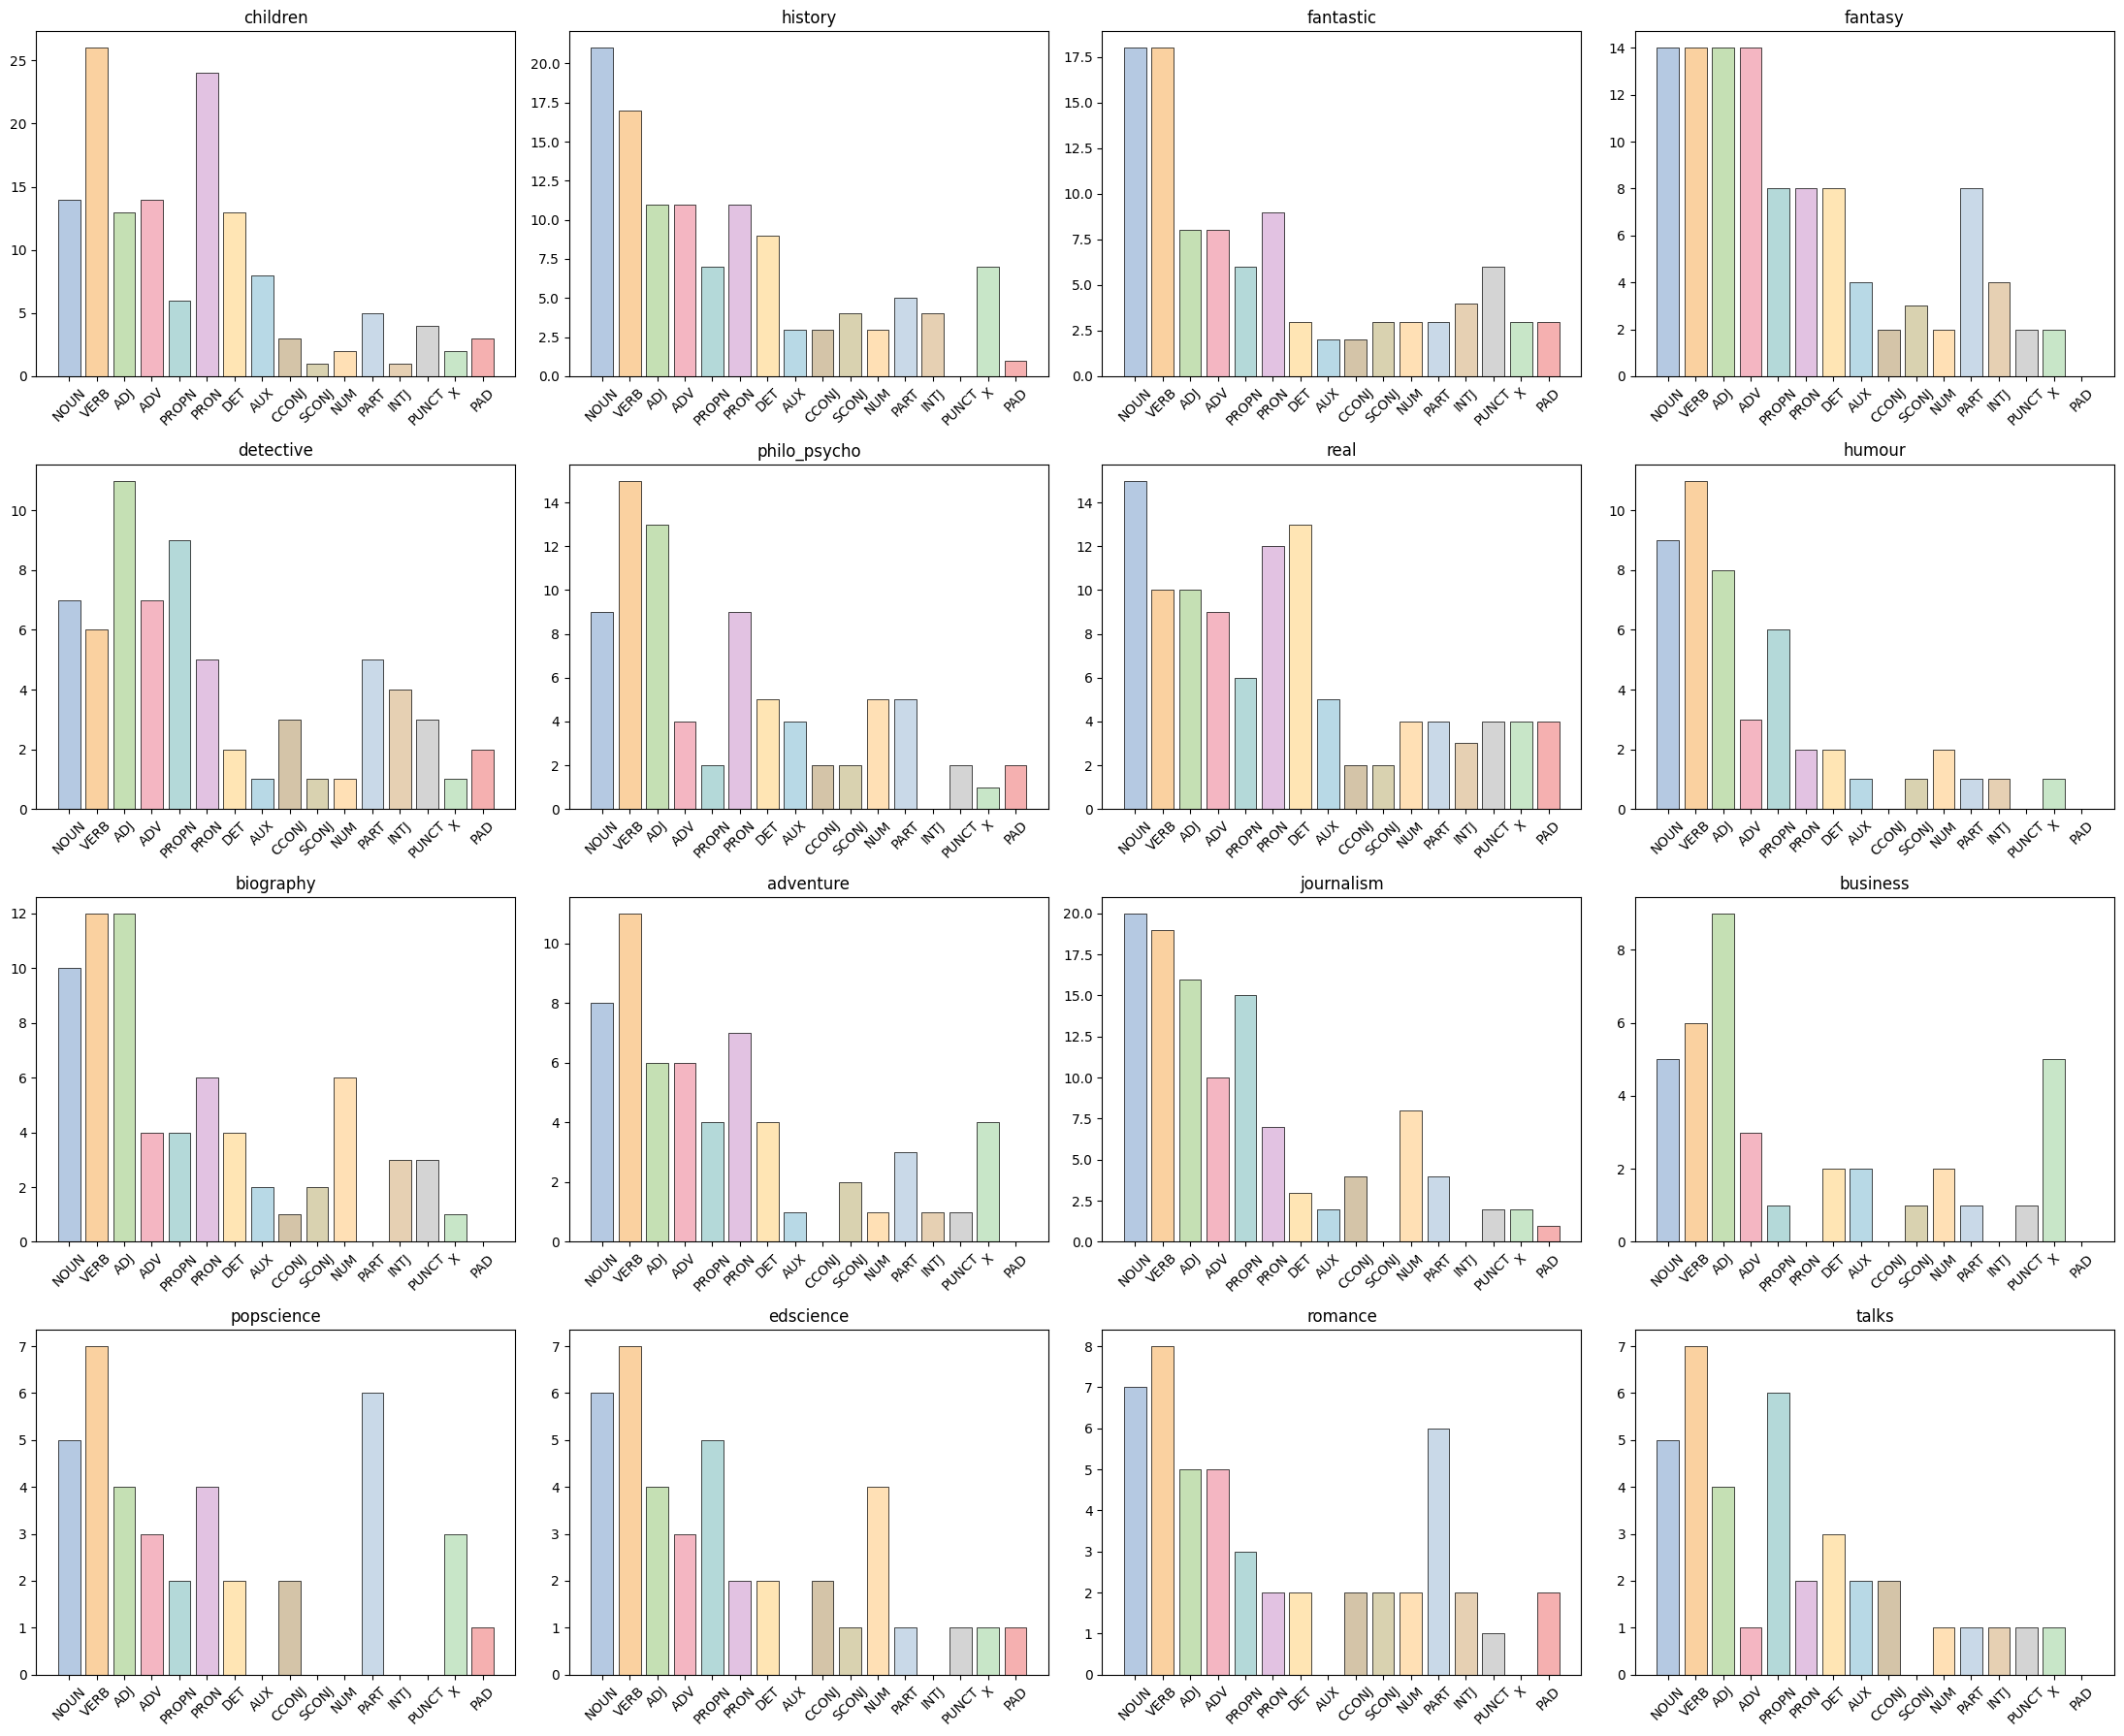

In [37]:
import ast
import math
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel("POS_authors.xlsx")

author_to_genre = {}
for genre, authors in author_genres.items():
    for author in authors:
        author_to_genre[author] = genre

genre_pos = {g: [] for g in author_genres}

for _, row in df.iterrows():
    author = str(row["author"]).strip()
    genre = author_to_genre.get(author[1:-1])
    if genre is None:
        continue

    feats = row["feature_names"]
    if isinstance(feats, str):
        feats = ast.literal_eval(feats)

    genre_pos[genre].extend(feats)

# Фиксированный порядок частей речи для всех графиков
fixed_pos_order = [
    "NOUN", "VERB", "ADJ", "ADV", "PROPN", "PRON", 
    "DET", "AUX", "CCONJ", "SCONJ", "NUM", "PART", 
    "INTJ", "PUNCT", "X", "PAD"
]

# Пастельные цвета
palette = {
    "NOUN": "#B5C9E2",  # pastel blue
    "VERB": "#FAD1A0",  # pastel orange
    "ADJ": "#C5E0B4",  # pastel green
    "ADV": "#F4B6C2",  # pastel pink
    "PROPN": "#B4D9D9",  # pastel teal
    "PRON": "#E2C2E2",  # pastel purple
    "DET": "#FFE5B4",  # pastel peach
    "AUX": "#B8D9E6",  # pastel light teal
    "CCONJ": "#D4C4A8",  # pastel beige
    "SCONJ": "#D9D2B0",  # pastel olive
    "NUM": "#FFE0B5",  # pastel cream
    "PART": "#C9D9E8",  # pastel light blue
    "INTJ": "#E6D0B3",  # pastel warm beige
    "PUNCT": "#D4D4D4",  # pastel gray
    "X": "#C8E6C8",  # pastel mint
    "PAD": "#F5B0B0",  # pastel coral
}

genres = list(genre_pos.keys())
n = len(genres)
cols = 4
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(22, 4.5 * rows))
axes = axes.ravel()

for i, genre in enumerate(genres):
    # Подсчет частот для фиксированного порядка тегов
    counts = []
    tags_with_data = []
    
    for tag in fixed_pos_order:
        count = genre_pos[genre].count(tag)
        tags_with_data.append(tag)
        counts.append(count)
    
    colors = [palette.get(tag, "#E8E8E8") for tag in tags_with_data]
    axes[i].bar(tags_with_data, counts, color=colors, edgecolor="black", linewidth=0.5)
    axes[i].set_title(genre)
    axes[i].tick_params(axis="x", rotation=45)

for j in range(len(genres), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [8]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import ast

# Словарь жанров
author_genres = {
    'children': [
        'Nosov', 'Volkov', 'Mikhalkov', 'Krapivin', 'Gaydar', 'Kassil',
        'Oseeva', 'Uspensky', 'Zhitkov', 'Oster', 'Dragunski', 'Prokofeva',
        'Rybakov', 'Abgaryan'
    ],
    'history': [
        'Simonov', 'Astafiev', 'Serafimovich', 'Furmanov', 'Sergeev-Tsenskij',
        'Kataev', 'Fadeev', 'Bykov', 'Chechin', 'Barinova', 'Marchik', 'Tamonikov'
    ],
    'fantastic': [
        'Adamov', 'Zemlyanoj', 'Efremov', 'Moshkov', 'Bushkov', 'Bulgakov',
        'Belyaev', 'Bulychev', 'AkuninBorisova', 'ShushpanovLouk'
    ],
    'fantasy': [
        'Lukyanenko', 'Zlotnikov', 'ZlotnikovNikolaev', 'Belyanin', 'Gelb',
        'Vlasova', 'Hoffman', 'Cherkasova', 'Shushpanov', 'Lungu', 'Salnikov'
    ],
    'detective': [
        'Derevyanko', 'Regentov', 'Akunin', 'Vainery', 'Marinina', 'Preobrazhensky', 'Strugatskie'
    ],
    'philo_psycho': [
        'Malevish', 'Epstein', 'Gusev', 'Losev', 'Makushinskiyi',
        'BonchOsmolovskaya', 'Aldanov', 'Dombrowski'
    ],
    'real': [
        'Dostoevsky', 'Tolstoy', 'Lermontov', 'SaltykovSchedrin', 'Mamin-Sibiryak',
        'Kuprin', 'Stepnova', 'Turgenev', 'Shukshin', 'Kozlov', 'Grekova'
    ],
    'humour': [
        'Zoschenko', 'Teffi', 'Voinovich', 'Aleshkovsky', 'Exler'
    ],
    'biography': [
        'Rubina', 'Aksakov', 'Chekhov', 'Gachev', 'Brustein', 'Granin', 'Dovlatov'
    ],
    'adventure': [
        'Soloviev', 'Solovyov', 'Pushkin', 'Grin', 'Kaverin', 'AkuninBrusnikin'
    ],
    'journalism': [
        'bashinform 202', 'VestnikRayona', 'pvlida', 'Gasymov', 'EdimDoma',
        'DoctorPiter', 'GazetaRu', 'nlobooks[ru]', 'GorVestnik', 'NakedScience','vestnik nsu', 'YasenevoMedia'
    ],
    'business': [
        'Vorotyntseva', 'Bobkova', 'Gusiatnikova', 'Kirsanova Anodina Aksenov'
    ],
    'popscience': [
        'Semihatov', 'Drobyshevsky', 'Shevtsov', 'Drobyshevsky Rupasova'
    ],
    'edscience': [
        'Gorelov', 'Alexander Hofman', 'Bakhtin', 'Knabe'
    ],
    'romance': [
        'Dubchak', 'Doronina', 'Mamina', 'Lubimova', 'Vladimirova'
    ],
    'talks': [
        'Convlab', 'TEDRus', 'Koni', 'Plevako'
    ]
}

def visualize_authors_radar(df):
    """
    Строит радарные диаграммы для каждого жанра с топ-3 признаками каждого автора
    на основе z-score
    
    Parameters:
    df: DataFrame с колонками 'authors', 'feature_names', 'z_score'
    """
    
    # Очищаем имена авторов от кавычек и лишних пробелов
    df['authors'] = df['authors'].apply(lambda x: x.strip("'\" ").strip())
    
    # Парсим feature_names если они в виде строки
    def parse_feature_names(x):
        if isinstance(x, str):
            try:
                return ast.literal_eval(x)
            except:
                return x
        return x
    
    df['feature_names'] = df['feature_names'].apply(parse_feature_names)
    df['z_score'] = df['z_score'].apply(parse_feature_names)
    
    # Создаем обратный словарь: автор -> жанр
    author_to_genre = {}
    for genre, authors in author_genres.items():
        for author in authors:
            author_to_genre[author] = genre
    
    # Добавляем колонку с жанром в DataFrame
    df['genre'] = df['authors'].map(author_to_genre)
    
    # Удаляем строки с неизвестными жанрами
    df = df.dropna(subset=['genre'])
    
    print(f"Найдено жанров: {df['genre'].nunique()}")
    print(f"Жанры: {df['genre'].unique()}")
    
    # Получаем список уникальных жанров
    genres = df['genre'].unique()
    
    # Пастельная цветовая палитра для авторов
    colors = [
        '#1E88E5', '#FF6D00', '#43A047', '#E53935', '#00ACC1',
        '#8E24AA', '#FDD835', '#6D4C41', '#5E35B1', '#FB8C00',
        '#D81B60', '#1E88E5', '#7CB342', '#F4511E', '#546E7A'
    ]
    
    # Для каждого жанра создаем отдельную диаграмму
    for genre in genres:
        genre_df = df[df['genre'] == genre].copy()
        
        if len(genre_df) == 0:
            continue
        
        print(f"\nОбработка жанра: {genre}, авторов: {len(genre_df)}")
        
        fig = go.Figure()
        
        # Для каждого автора в жанре берем топ-3 признака по абсолютному значению z-score
        for i, (_, row) in enumerate(genre_df.iterrows()):
            author = row['authors']
            feature_names = row['feature_names']
            z_scores = row['z_score']
            
            # Проверяем, что данные не пустые и являются списками
            if not isinstance(feature_names, (list, tuple)) or not isinstance(z_scores, (list, tuple)):
                print(f"Предупреждение: у автора {author} данные не в формате списка")
                continue
            
            if len(feature_names) == 0 or len(z_scores) == 0:
                print(f"Предупреждение: у автора {author} пустые данные")
                continue
            
            # Приводим к одинаковой длине
            min_length = min(len(feature_names), len(z_scores))
            feature_names = feature_names[:min_length]
            z_scores = z_scores[:min_length]
            
            # Создаем список кортежей (имя признака, z-score)
            feature_data = list(zip(feature_names, z_scores))
            
            # Сортируем по абсолютному значению z-score (от большего к меньшему)
            feature_data.sort(key=lambda x: abs(x[1]), reverse=True)
            # Берем топ-3
            top_features = feature_data[:3]
            
            if len(top_features) == 0:
                print(f"Предупреждение: у автора {author} нет топ-3 признаков")
                continue
            
            # Извлекаем данные для топ-3 признаков
            top_feature_names = [f[0] for f in top_features]
            top_z_scores = [f[1] for f in top_features]
            
            # Создаем custom hover data
            custom_hover_data = []
            for feat_name, z_val in zip(top_feature_names, top_z_scores):
                custom_hover_data.append(
                    f"Feature: {feat_name} | |Z-Score|: {abs(z_val):.3f}"
                )
            
            # Добавляем трассу на радар (используем абсолютные значения z-score)
            fig.add_trace(go.Scatterpolar(
                r=[abs(v) for v in top_z_scores],
                theta=top_feature_names,
                fill='toself',
                name=author,
                hovertemplate='<b>Author:</b> ' + author + '<br>' +
                             '<b>Genre:</b> ' + genre + '<br>' +
                             '<b>Feature:</b> %{theta}<br>' +
                             '<b>|Z-Score|:</b> %{r:.3f}<br>' +
                             '<extra></extra>',
                line=dict(color=colors[i % len(colors)], width=2),
                opacity=0.7
            ))
        
        # Если нет трасс, пропускаем жанр
        if len(fig.data) == 0:
            print(f"Нет данных для жанра {genre}")
            continue
        
        # Определяем максимальное абсолютное значение z-score для шкалы
        max_val = 0
        for _, row in genre_df.iterrows():
            z_scores = row['z_score']
            if isinstance(z_scores, (list, tuple)) and len(z_scores) > 0:
                z_scores_abs = [abs(z) for z in z_scores]
                top_3_vals = sorted(z_scores_abs, reverse=True)[:3]
                if top_3_vals:
                    max_val = max(max_val, max(top_3_vals))
        
        # Настройка внешнего вида диаграммы
        fig.update_layout(
            polar=dict(
                radialaxis=dict(
                    visible=True,
                    range=[0, max_val * 1.2] if max_val > 0 else [0, 1],
                    tickfont=dict(size=10),
                    gridcolor='lightgray',
                    title=dict(text="|Z-Score|", font=dict(size=10))
                ),
                angularaxis=dict(
                    tickfont=dict(size=11, weight='bold'),
                    gridcolor='lightgray',
                    rotation=90
                )
            ),
            title=dict(
                text=f"<b>{genre}</b><br>Топ-3 признака по |z-score| для каждого автора",
                x=0.5,
                xanchor='center',
                font=dict(size=16)
            ),
            showlegend=True,
            legend=dict(
                x=1.05,
                y=1,
                xanchor='left',
                yanchor='top',
                bgcolor='rgba(255,255,255,0.8)',
                bordercolor='black',
                borderwidth=1
            ),
            width=900,
            height=700,
            template='plotly_white'
        )
        
        fig.show()
        print(f"Диаграмма для жанра {genre} создана")

# Пример использования:
df = pd.read_excel("features_authors.xlsx")
visualize_authors_radar(df)

Найдено жанров: 16
Жанры: <StringArray>
[    'children',    'fantastic',    'biography',    'adventure',
    'detective', 'philo_psycho',       'humour',    'edscience',
      'history',   'journalism',      'fantasy',     'business',
        'talks',      'romance',         'real',   'popscience']
Length: 16, dtype: str

Обработка жанра: children, авторов: 14


Диаграмма для жанра children создана

Обработка жанра: fantastic, авторов: 10


Диаграмма для жанра fantastic создана

Обработка жанра: biography, авторов: 7


Диаграмма для жанра biography создана

Обработка жанра: adventure, авторов: 6


Диаграмма для жанра adventure создана

Обработка жанра: detective, авторов: 7


...

Диаграмма для жанра business создана

Обработка жанра: talks, авторов: 4


Диаграмма для жанра talks создана

Обработка жанра: romance, авторов: 5


Диаграмма для жанра romance создана

Обработка жанра: real, авторов: 11


Диаграмма для жанра real создана

Обработка жанра: popscience, авторов: 4


Диаграмма для жанра popscience создана


In [ ]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import ast

def normalize_feature(feature):
    """
    Нормализует признак: сортирует части признака по алфавиту
    'PROPN NUM' -> 'NUM PROPN' -> 'NUM PROPN' (после сортировки)
    'ADV PRON' -> 'ADV PRON' (останется как есть)
    """
    if isinstance(feature, str):
        parts = feature.strip().split()
        if len(parts) > 1:
            # Сортируем части для унификации
            parts.sort()
            return ' '.join(parts)
    return feature

def visualize_authors_radar(df):
    """
    Строит радарные диаграммы для каждого жанра с топ-3 признаками каждого автора
    на основе z-score
    
    Parameters:
    df: DataFrame с колонками 'authors', 'features_short', 'z_score'
    """
    
    # Очищаем имена авторов от кавычек и лишних пробелов
    df['authors'] = df['authors'].apply(lambda x: x.strip("'\" ").strip())
    
    # Парсим features_short если они в виде строки
    def parse_features_short(x):
        if isinstance(x, str):
            try:
                return ast.literal_eval(x)
            except:
                return x
        return x
    
    df['features_short'] = df['features_short'].apply(parse_features_short)
    df['z_score'] = df['z_score'].apply(parse_features_short)
    
    # Нормализуем все признаки (сортируем части для унификации)
    df['features_short'] = df['features_short'].apply(
        lambda features: [normalize_feature(f) for f in features] if isinstance(features, list) else features
    )
    
    # Создаем обратный словарь: автор -> жанр
    author_to_genre = {}
    for genre, authors in author_genres.items():
        for author in authors:
            author_to_genre[author] = genre
    
    # Добавляем колонку с жанром в DataFrame
    df['genre'] = df['authors'].map(author_to_genre)
    
    # Удаляем строки с неизвестными жанрами
    df = df.dropna(subset=['genre'])
    
    # Получаем список уникальных жанров
    genres = df['genre'].unique()
    
    # Яркая цветовая палитра для авторов
    colors = [
        '#1E88E5', '#FF6D00', '#43A047', '#E53935', '#00ACC1',
        '#8E24AA', '#FDD835', '#6D4C41', '#5E35B1', '#FB8C00',
        '#D81B60', '#7CB342', '#F4511E', '#546E7A', '#FFB300'
    ]
    
    # Для каждого жанра создаем отдельную диаграмму
    for genre in genres:
        genre_df = df[df['genre'] == genre].copy()
        
        if len(genre_df) == 0:
            continue
                
        fig = go.Figure()
        
        # Для каждого автора в жанре берем топ-3 признака по абсолютному значению z-score
        for i, (_, row) in enumerate(genre_df.iterrows()):
            author = row['authors']
            features_short = row['features_short']
            z_scores = row['z_score']
            
            # Проверяем, что данные не пустые и являются списками
            if not isinstance(features_short, (list, tuple)) or not isinstance(z_scores, (list, tuple)):
                print(f"Предупреждение: у автора {author} данные не в формате списка")
                continue
            
            if len(features_short) == 0 or len(z_scores) == 0:
                print(f"Предупреждение: у автора {author} пустые данные")
                continue
            
            # Приводим к одинаковой длине
            min_length = min(len(features_short), len(z_scores))
            features_short = features_short[:min_length]
            z_scores = z_scores[:min_length]
            
            # Группируем признаки с одинаковым нормализованным именем (суммируем |z-score|)
            feature_dict = {}
            for feat, z in zip(features_short, z_scores):
                if feat in feature_dict:
                    # Если признак уже есть, суммируем абсолютные значения z-score
                    feature_dict[feat] = feature_dict[feat] + abs(z)
                else:
                    feature_dict[feat] = abs(z)
            
            # Создаем список кортежей (имя признака, суммарный |z-score|)
            feature_data = [(feat, val) for feat, val in feature_dict.items()]
            
            # Сортируем по суммарному значению |z-score| (от большего к меньшему)
            feature_data.sort(key=lambda x: x[1], reverse=True)
            # Берем топ-3
            top_features = feature_data[:3]
            
            if len(top_features) == 0:
                print(f"Предупреждение: у автора {author} нет топ-3 признаков")
                continue
            
            # Извлекаем данные для топ-3 признаков
            top_features_short = [f[0] for f in top_features]
            top_z_scores = [f[1] for f in top_features]  # Это уже абсолютные значения
            
            # Создаем custom hover data
            custom_hover_data = []
            for feat_name, z_val in zip(top_features_short, top_z_scores):
                custom_hover_data.append(
                    f"Feature: {feat_name} | |Z-Score|: {z_val:.3f}"
                )
            
            # Добавляем трассу на радар
            fig.add_trace(go.Scatterpolar(
                r=top_z_scores,  # Уже абсолютные значения
                theta=top_features_short,
                fill='toself',
                name=author,
                hovertemplate='<b>Author:</b> ' + author + '<br>' +
                             '<b>Genre:</b> ' + genre + '<br>' +
                             '<b>Feature:</b> %{theta}<br>' +
                             '<b>|Z-Score| (sum):</b> %{r:.3f}<br>' +
                             '<extra></extra>',
                line=dict(color=colors[i % len(colors)], width=2),
                opacity=0.7
            ))
        
        # Если нет трасс, пропускаем жанр
        if len(fig.data) == 0:
            print(f"Нет данных для жанра {genre}")
            continue
        
        # Определяем максимальное значение для шкалы
        max_val = 0
        for trace in fig.data:
            if len(trace.r) > 0:
                max_val = max(max_val, max(trace.r))
        
        # Настройка внешнего вида диаграммы
        fig.update_layout(
            polar=dict(
                radialaxis=dict(
                    visible=True,
                    range=[0, max_val * 1.2] if max_val > 0 else [0, 1],
                    tickfont=dict(size=10),
                    gridcolor='lightgray',
                    title=dict(text="Суммарный |Z-Score|", font=dict(size=10))
                ),
                angularaxis=dict(
                    tickfont=dict(size=11, weight='bold'),
                    gridcolor='lightgray',
                    rotation=90
                )
            ),
            title=dict(
                text=f"<b>{genre}</b><br>Топ-3 признака по суммарному |z-score| для каждого автора",
                x=0.5,
                xanchor='center',
                font=dict(size=16)
            ),
            showlegend=True,
            legend=dict(
                x=1.05,
                y=1,
                xanchor='left',
                yanchor='top',
                bgcolor='rgba(255,255,255,0.8)',
                bordercolor='black',
                borderwidth=1
            ),
            width=900,
            height=700,
            template='plotly_white'
        )
        
        fig.show()

# Пример использования:
df = pd.read_excel("features_authors.xlsx")
visualize_authors_radar(df)

In [ ]:
#В.В. Быков, автор военной прозы, находится рядом с Джек Гельб (городское фэнтези) и Ксенией Власовой (любовное фэнтези).
# Константин Симонов, автор военной прозы и мемуаров, В.А.Каверин - приключенческих романов и произведений в жанре социалистического реализма, Аркадий и Георгий Вайнеры - детективов, триллеров и милицейских производственных романов, находятся в одном кластере вместе со Славой Дорониной, писательницей любовных романов. 

In [11]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import ast

def normalize_feature(feature):
    """
    Нормализует признак: сортирует части признака по алфавиту
    'PROPN NUM' -> 'NUM PROPN' -> 'NUM PROPN' (после сортировки)
    'ADV PRON' -> 'ADV PRON' (останется как есть)
    """
    if isinstance(feature, str):
        parts = feature.strip().split()
        if len(parts) > 1:
            # Сортируем части для унификации
            parts.sort()
            return ' '.join(parts)
    return feature

def visualize_authors_radar(df):
    """
    Строит радарные диаграммы для каждого жанра с топ-3 признаками каждого автора
    на основе z-score
    
    Parameters:
    df: DataFrame с колонками 'authors', 'features_short', 'z_score'
    """
    
    # Очищаем имена авторов от кавычек и лишних пробелов
    df['authors'] = df['authors'].apply(lambda x: x.strip("'\" ").strip())
    
    # Парсим features_short если они в виде строки
    def parse_features_short(x):
        if isinstance(x, str):
            try:
                return ast.literal_eval(x)
            except:
                return x
        return x
    
    df['features_short'] = df['features_short'].apply(parse_features_short)
    df['z_score'] = df['z_score'].apply(parse_features_short)
    
    # Нормализуем все признаки (сортируем части для унификации)
    df['features_short'] = df['features_short'].apply(
        lambda features: [normalize_feature(f) for f in features] if isinstance(features, list) else features
    )
    author_genres = {'pseudonims': ['Grekova', 'Akunin', 'AkuninBrusnikin', 'AkuninBorisova'],'BykovGelbVlasova': ['Bykov', 'Gelb', 'Vlasova'],
                     'SimonovKaverinVaineryDoronina': ['Simonov', 'Kaverin', 'Vainery', 'Doronina'],
                     'SolovievSolovyov':['Soloviev', 'Solovyov']}
    # Создаем обратный словарь: автор -> жанр
    author_to_genre = {}
    for genre, authors in author_genres.items():
        for author in authors:
            author_to_genre[author] = genre
    
    # Добавляем колонку с жанром в DataFrame
    df['genre'] = df['authors'].map(author_to_genre)
    
    # Удаляем строки с неизвестными жанрами
    df = df.dropna(subset=['genre'])
    
    # Получаем список уникальных жанров
    genres = df['genre'].unique()
    
    # Яркая цветовая палитра для авторов
    colors = [
        '#1E88E5', '#FF6D00', '#43A047', '#E53935', '#00ACC1',
        '#8E24AA', '#FDD835', '#6D4C41', '#5E35B1', '#FB8C00',
        '#D81B60', '#7CB342', '#F4511E', '#546E7A', '#FFB300'
    ]
    
    # Для каждого жанра создаем отдельную диаграмму
    for genre in genres:
        genre_df = df[df['genre'] == genre].copy()
        
        if len(genre_df) == 0:
            continue
                
        fig = go.Figure()
        
        # Для каждого автора в жанре берем топ-3 признака по абсолютному значению z-score
        for i, (_, row) in enumerate(genre_df.iterrows()):
            author = row['authors']
            features_short = row['features_short']
            z_scores = row['z_score']
            
            # Проверяем, что данные не пустые и являются списками
            if not isinstance(features_short, (list, tuple)) or not isinstance(z_scores, (list, tuple)):
                print(f"Предупреждение: у автора {author} данные не в формате списка")
                continue
            
            if len(features_short) == 0 or len(z_scores) == 0:
                print(f"Предупреждение: у автора {author} пустые данные")
                continue
            
            # Приводим к одинаковой длине
            min_length = min(len(features_short), len(z_scores))
            features_short = features_short[:min_length]
            z_scores = z_scores[:min_length]
            
            # Группируем признаки с одинаковым нормализованным именем (суммируем |z-score|)
            feature_dict = {}
            for feat, z in zip(features_short, z_scores):
                if feat in feature_dict:
                    # Если признак уже есть, суммируем абсолютные значения z-score
                    feature_dict[feat] = feature_dict[feat] + abs(z)
                else:
                    feature_dict[feat] = abs(z)
            
            # Создаем список кортежей (имя признака, суммарный |z-score|)
            feature_data = [(feat, val) for feat, val in feature_dict.items()]
            
            # Сортируем по суммарному значению |z-score| (от большего к меньшему)
            feature_data.sort(key=lambda x: x[1], reverse=True)
            # Берем топ-3
            top_features = feature_data[:3]
            
            if len(top_features) == 0:
                print(f"Предупреждение: у автора {author} нет топ-3 признаков")
                continue
            
            # Извлекаем данные для топ-3 признаков
            top_features_short = [f[0] for f in top_features]
            top_z_scores = [f[1] for f in top_features]  # Это уже абсолютные значения
            
            # Создаем custom hover data
            custom_hover_data = []
            for feat_name, z_val in zip(top_features_short, top_z_scores):
                custom_hover_data.append(
                    f"Feature: {feat_name} | |Z-Score|: {z_val:.3f}"
                )
            
            # Добавляем трассу на радар
            fig.add_trace(go.Scatterpolar(
                r=top_z_scores,  # Уже абсолютные значения
                theta=top_features_short,
                fill='toself',
                name=author,
                hovertemplate='<b>Author:</b> ' + author + '<br>' +
                             '<b>Genre:</b> ' + genre + '<br>' +
                             '<b>Feature:</b> %{theta}<br>' +
                             '<b>|Z-Score| (sum):</b> %{r:.3f}<br>' +
                             '<extra></extra>',
                line=dict(color=colors[i % len(colors)], width=2),
                opacity=0.7
            ))
        
        # Если нет трасс, пропускаем жанр
        if len(fig.data) == 0:
            print(f"Нет данных для жанра {genre}")
            continue
        
        # Определяем максимальное значение для шкалы
        max_val = 0
        for trace in fig.data:
            if len(trace.r) > 0:
                max_val = max(max_val, max(trace.r))
        
        # Настройка внешнего вида диаграммы
        fig.update_layout(
            polar=dict(
                radialaxis=dict(
                    visible=True,
                    range=[0, max_val * 1.2] if max_val > 0 else [0, 1],
                    tickfont=dict(size=10),
                    gridcolor='lightgray',
                    title=dict(text="Суммарный |Z-Score|", font=dict(size=10))
                ),
                angularaxis=dict(
                    tickfont=dict(size=11, weight='bold'),
                    gridcolor='lightgray',
                    rotation=90
                )
            ),
            title=dict(
                text=f"<b>{genre}</b><br>Топ-3 признака по суммарному |z-score| для каждого автора",
                x=0.5,
                xanchor='center',
                font=dict(size=16)
            ),
            showlegend=True,
            legend=dict(
                x=1.05,
                y=1,
                xanchor='left',
                yanchor='top',
                bgcolor='rgba(255,255,255,0.8)',
                bordercolor='black',
                borderwidth=1
            ),
            width=900,
            height=700,
            template='plotly_white'
        )
        
        fig.show()

# Пример использования:
df = pd.read_excel("features_authors.xlsx")
visualize_authors_radar(df)

In [13]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import ast

def normalize_feature(feature):
    """
    Нормализует признак: сортирует части признака по алфавиту
    'PROPN NUM' -> 'NUM PROPN' -> 'NUM PROPN' (после сортировки)
    'ADV PRON' -> 'ADV PRON' (останется как есть)
    """
    if isinstance(feature, str):
        parts = feature.strip().split()
        if len(parts) > 1:
            # Сортируем части для унификации
            parts.sort()
            return ' '.join(parts)
    return feature

def visualize_authors_radar(df):
    """
    Строит радарные диаграммы для каждого жанра с топ-3 признаками каждого автора
    на основе z-score
    
    Parameters:
    df: DataFrame с колонками 'authors', 'features_short', 'z_score'
    """
    
    # Очищаем имена авторов от кавычек и лишних пробелов
    df['authors'] = df['authors'].apply(lambda x: x.strip("'\" ").strip())
    
    # Парсим features_short если они в виде строки
    def parse_features_short(x):
        if isinstance(x, str):
            try:
                return ast.literal_eval(x)
            except:
                return x
        return x
    
    df['deprel'] = df['deprel'].apply(parse_features_short)
    df['z_score'] = df['z_score'].apply(parse_features_short)
    
    # Нормализуем все признаки (сортируем части для унификации)
    df['deprel'] = df['deprel'].apply(
        lambda features: [normalize_feature(f) for f in features] if isinstance(features, list) else features
    )

    # Создаем обратный словарь: автор -> жанр
    author_to_genre = {}
    for genre, authors in author_genres.items():
        for author in authors:
            author_to_genre[author] = genre
    
    # Добавляем колонку с жанром в DataFrame
    df['genre'] = df['authors'].map(author_to_genre)
    
    # Удаляем строки с неизвестными жанрами
    df = df.dropna(subset=['genre'])
    
    # Получаем список уникальных жанров
    genres = df['genre'].unique()
    
    # Яркая цветовая палитра для авторов
    colors = [
        '#1E88E5', '#FF6D00', '#43A047', '#E53935', '#00ACC1',
        '#8E24AA', '#FDD835', '#6D4C41', '#5E35B1', '#FB8C00',
        '#D81B60', '#7CB342', '#F4511E', '#546E7A', '#FFB300'
    ]
    
    # Для каждого жанра создаем отдельную диаграмму
    for genre in genres:
        genre_df = df[df['genre'] == genre].copy()
        
        if len(genre_df) == 0:
            continue
                
        fig = go.Figure()
        
        # Для каждого автора в жанре берем топ-3 признака по абсолютному значению z-score
        for i, (_, row) in enumerate(genre_df.iterrows()):
            author = row['authors']
            features_short = row['deprel']
            z_scores = row['z_score']
            
            # Проверяем, что данные не пустые и являются списками
            if not isinstance(features_short, (list, tuple)) or not isinstance(z_scores, (list, tuple)):
                print(f"Предупреждение: у автора {author} данные не в формате списка")
                continue
            
            if len(features_short) == 0 or len(z_scores) == 0:
                print(f"Предупреждение: у автора {author} пустые данные")
                continue
            
            # Приводим к одинаковой длине
            min_length = min(len(features_short), len(z_scores))
            features_short = features_short[:min_length]
            z_scores = z_scores[:min_length]
            
            # Группируем признаки с одинаковым нормализованным именем (суммируем |z-score|)
            feature_dict = {}
            for feat, z in zip(features_short, z_scores):
                if feat in feature_dict:
                    # Если признак уже есть, суммируем абсолютные значения z-score
                    feature_dict[feat] = feature_dict[feat] + abs(z)
                else:
                    feature_dict[feat] = abs(z)
            
            # Создаем список кортежей (имя признака, суммарный |z-score|)
            feature_data = [(feat, val) for feat, val in feature_dict.items()]
            
            # Сортируем по суммарному значению |z-score| (от большего к меньшему)
            feature_data.sort(key=lambda x: x[1], reverse=True)
            # Берем топ-3
            top_features = feature_data[:3]
            
            if len(top_features) == 0:
                print(f"Предупреждение: у автора {author} нет топ-3 признаков")
                continue
            
            # Извлекаем данные для топ-3 признаков
            top_features_short = [f[0] for f in top_features]
            top_z_scores = [f[1] for f in top_features]  # Это уже абсолютные значения
            
            # Создаем custom hover data
            custom_hover_data = []
            for feat_name, z_val in zip(top_features_short, top_z_scores):
                custom_hover_data.append(
                    f"Feature: {feat_name} | |Z-Score|: {z_val:.3f}"
                )
            
            # Добавляем трассу на радар
            fig.add_trace(go.Scatterpolar(
                r=top_z_scores,  # Уже абсолютные значения
                theta=top_features_short,
                fill='toself',
                name=author,
                hovertemplate='<b>Author:</b> ' + author + '<br>' +
                             '<b>Genre:</b> ' + genre + '<br>' +
                             '<b>Feature:</b> %{theta}<br>' +
                             '<b>|Z-Score| (sum):</b> %{r:.3f}<br>' +
                             '<extra></extra>',
                line=dict(color=colors[i % len(colors)], width=2),
                opacity=0.7
            ))
        
        # Если нет трасс, пропускаем жанр
        if len(fig.data) == 0:
            print(f"Нет данных для жанра {genre}")
            continue
        
        # Определяем максимальное значение для шкалы
        max_val = 0
        for trace in fig.data:
            if len(trace.r) > 0:
                max_val = max(max_val, max(trace.r))
        
        # Настройка внешнего вида диаграммы
        fig.update_layout(
            polar=dict(
                radialaxis=dict(
                    visible=True,
                    range=[0, max_val * 1.2] if max_val > 0 else [0, 1],
                    tickfont=dict(size=10),
                    gridcolor='lightgray',
                    title=dict(text="Суммарный |Z-Score|", font=dict(size=10))
                ),
                angularaxis=dict(
                    tickfont=dict(size=11, weight='bold'),
                    gridcolor='lightgray',
                    rotation=90
                )
            ),
            title=dict(
                text=f"<b>{genre}</b><br>Топ-3 отношения по суммарному |z-score| для каждого автора",
                x=0.5,
                xanchor='center',
                font=dict(size=16)
            ),
            showlegend=True,
            legend=dict(
                x=1.05,
                y=1,
                xanchor='left',
                yanchor='top',
                bgcolor='rgba(255,255,255,0.8)',
                bordercolor='black',
                borderwidth=1
            ),
            width=900,
            height=700,
            template='plotly_white'
        )
        
        fig.show()

# Пример использования:
df = pd.read_excel("features_authors.xlsx")
visualize_authors_radar(df)

In [12]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import ast

def normalize_feature(feature):
    """
    Нормализует признак: сортирует части признака по алфавиту
    'PROPN NUM' -> 'NUM PROPN' -> 'NUM PROPN' (после сортировки)
    'ADV PRON' -> 'ADV PRON' (останется как есть)
    """
    if isinstance(feature, str):
        parts = feature.strip().split()
        if len(parts) > 1:
            # Сортируем части для унификации
            parts.sort()
            return ' '.join(parts)
    return feature

def visualize_authors_radar(df):
    """
    Строит радарные диаграммы для каждого жанра с топ-3 признаками каждого автора
    на основе z-score
    
    Parameters:
    df: DataFrame с колонками 'authors', 'features_short', 'z_score'
    """
    
    # Очищаем имена авторов от кавычек и лишних пробелов
    df['authors'] = df['authors'].apply(lambda x: x.strip("'\" ").strip())
    
    # Парсим features_short если они в виде строки
    def parse_features_short(x):
        if isinstance(x, str):
            try:
                return ast.literal_eval(x)
            except:
                return x
        return x
    
    df['deprel'] = df['deprel'].apply(parse_features_short)
    df['z_score'] = df['z_score'].apply(parse_features_short)
    
    # Нормализуем все признаки (сортируем части для унификации)
    df['deprel'] = df['deprel'].apply(
        lambda features: [normalize_feature(f) for f in features] if isinstance(features, list) else features
    )
    author_genres = {'pseudonims': ['Grekova', 'Akunin', 'AkuninBrusnikin', 'AkuninBorisova'],'BykovGelbVlasova': ['Bykov', 'Gelb', 'Vlasova'],
                     'SimonovKaverinVaineryDoronina': ['Simonov', 'Kaverin', 'Vainery', 'Doronina'],
                     'SolovievSolovyov':['Soloviev', 'Solovyov']}
    # Создаем обратный словарь: автор -> жанр
    author_to_genre = {}
    for genre, authors in author_genres.items():
        for author in authors:
            author_to_genre[author] = genre
    
    # Добавляем колонку с жанром в DataFrame
    df['genre'] = df['authors'].map(author_to_genre)
    
    # Удаляем строки с неизвестными жанрами
    df = df.dropna(subset=['genre'])
    
    # Получаем список уникальных жанров
    genres = df['genre'].unique()
    
    # Яркая цветовая палитра для авторов
    colors = [
        '#1E88E5', '#FF6D00', '#43A047', '#E53935', '#00ACC1',
        '#8E24AA', '#FDD835', '#6D4C41', '#5E35B1', '#FB8C00',
        '#D81B60', '#7CB342', '#F4511E', '#546E7A', '#FFB300'
    ]
    
    # Для каждого жанра создаем отдельную диаграмму
    for genre in genres:
        genre_df = df[df['genre'] == genre].copy()
        
        if len(genre_df) == 0:
            continue
                
        fig = go.Figure()
        
        # Для каждого автора в жанре берем топ-3 признака по абсолютному значению z-score
        for i, (_, row) in enumerate(genre_df.iterrows()):
            author = row['authors']
            features_short = row['deprel']
            z_scores = row['z_score']
            
            # Проверяем, что данные не пустые и являются списками
            if not isinstance(features_short, (list, tuple)) or not isinstance(z_scores, (list, tuple)):
                print(f"Предупреждение: у автора {author} данные не в формате списка")
                continue
            
            if len(features_short) == 0 or len(z_scores) == 0:
                print(f"Предупреждение: у автора {author} пустые данные")
                continue
            
            # Приводим к одинаковой длине
            min_length = min(len(features_short), len(z_scores))
            features_short = features_short[:min_length]
            z_scores = z_scores[:min_length]
            
            # Группируем признаки с одинаковым нормализованным именем (суммируем |z-score|)
            feature_dict = {}
            for feat, z in zip(features_short, z_scores):
                if feat in feature_dict:
                    # Если признак уже есть, суммируем абсолютные значения z-score
                    feature_dict[feat] = feature_dict[feat] + abs(z)
                else:
                    feature_dict[feat] = abs(z)
            
            # Создаем список кортежей (имя признака, суммарный |z-score|)
            feature_data = [(feat, val) for feat, val in feature_dict.items()]
            
            # Сортируем по суммарному значению |z-score| (от большего к меньшему)
            feature_data.sort(key=lambda x: x[1], reverse=True)
            # Берем топ-3
            top_features = feature_data[:3]
            
            if len(top_features) == 0:
                print(f"Предупреждение: у автора {author} нет топ-3 признаков")
                continue
            
            # Извлекаем данные для топ-3 признаков
            top_features_short = [f[0] for f in top_features]
            top_z_scores = [f[1] for f in top_features]  # Это уже абсолютные значения
            
            # Создаем custom hover data
            custom_hover_data = []
            for feat_name, z_val in zip(top_features_short, top_z_scores):
                custom_hover_data.append(
                    f"Feature: {feat_name} | |Z-Score|: {z_val:.3f}"
                )
            
            # Добавляем трассу на радар
            fig.add_trace(go.Scatterpolar(
                r=top_z_scores,  # Уже абсолютные значения
                theta=top_features_short,
                fill='toself',
                name=author,
                hovertemplate='<b>Author:</b> ' + author + '<br>' +
                             '<b>Genre:</b> ' + genre + '<br>' +
                             '<b>Feature:</b> %{theta}<br>' +
                             '<b>|Z-Score| (sum):</b> %{r:.3f}<br>' +
                             '<extra></extra>',
                line=dict(color=colors[i % len(colors)], width=2),
                opacity=0.7
            ))
        
        # Если нет трасс, пропускаем жанр
        if len(fig.data) == 0:
            print(f"Нет данных для жанра {genre}")
            continue
        
        # Определяем максимальное значение для шкалы
        max_val = 0
        for trace in fig.data:
            if len(trace.r) > 0:
                max_val = max(max_val, max(trace.r))
        
        # Настройка внешнего вида диаграммы
        fig.update_layout(
            polar=dict(
                radialaxis=dict(
                    visible=True,
                    range=[0, max_val * 1.2] if max_val > 0 else [0, 1],
                    tickfont=dict(size=10),
                    gridcolor='lightgray',
                    title=dict(text="Суммарный |Z-Score|", font=dict(size=10))
                ),
                angularaxis=dict(
                    tickfont=dict(size=11, weight='bold'),
                    gridcolor='lightgray',
                    rotation=90
                )
            ),
            title=dict(
                text=f"<b>{genre}</b><br>Топ-3 признака по суммарному |z-score| для каждого автора",
                x=0.5,
                xanchor='center',
                font=dict(size=16)
            ),
            showlegend=True,
            legend=dict(
                x=1.05,
                y=1,
                xanchor='left',
                yanchor='top',
                bgcolor='rgba(255,255,255,0.8)',
                bordercolor='black',
                borderwidth=1
            ),
            width=900,
            height=700,
            template='plotly_white'
        )
        
        fig.show()

# Пример использования:
df = pd.read_excel("features_authors.xlsx")
visualize_authors_radar(df)